In [1]:
# importing necessary packages 
import numpy as np
import pandas as pd
from os import path
from PIL import Image
#from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import statsmodels.api as sm
import nltk; nltk.download('punkt'); nltk.download('stopwords')
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package punkt to /Users/annablock/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/annablock/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
demographics = pd.read_csv("data/Dartmouth Data Set- SIRS .xlsx - Demographics.csv")
print(demographics.head())
print(demographics.shape)
print(demographics['Local ID'].nunique())

local_ids = demographics['Local ID']

   Local ID Date Enrolled in START  Status Status Date  \
0  11128335               7/1/2010  Active   7/22/2010   
1  11134104              11/1/2011  Active  11/30/2011   
2  11138520               5/1/2012  Active   5/21/2012   
3  11132094               5/1/2013  Active    5/9/2013   
4   975134C               7/1/2014  Active    7/1/2014   

                       Time Enrolled in START  \
0  Business Hours (Monday - Friday 8am - 5pm)   
1  Business Hours (Monday - Friday 8am - 5pm)   
2  Business Hours (Monday - Friday 8am - 5pm)   
3  Business Hours (Monday - Friday 8am - 5pm)   
4  Business Hours (Monday - Friday 8am - 5pm)   

        Source of referral to START Suitability of enrollment in START  \
0  Case Manager/Service Coordinator                        Appropriate   
1  Case Manager/Service Coordinator                        Appropriate   
2  Case Manager/Service Coordinator                        Appropriate   
3  Case Manager/Service Coordinator                        A

In [3]:
abc = pd.read_csv("data/Dartmouth Data Set- SIRS .xlsx - ABC Data.csv")
print(abc.head())
print(abc.shape)
print(abc['Local ID'].nunique())

abc_filtered = abc[abc['Local ID'].isin(local_ids)]
print(abc_filtered['Local ID'].nunique())

   Local ID Date Reviewed Type of Service  Irritability/Agitation  \
0  11163106      2/1/2013          Intake                     9.0   
1  11163106      2/1/2013          Intake                     9.0   
2  11134102      3/1/2013          Intake                    21.0   
3  11134102      3/1/2013          Intake                    21.0   
4  11134102     11/1/2014   Re-evaluation                    15.0   

   Lethargy/Social Withdrawal  Stereotypic Behavior  \
0                        16.0                   0.0   
1                        16.0                   0.0   
2                        21.0                   2.0   
3                        21.0                   2.0   
4                        11.0                   2.0   

   Hyperactivity/Noncompliance  Inappropriate Speech  
0                          0.0                   0.0  
1                          0.0                   0.0  
2                          9.0                   2.0  
3                          9.0    

In [4]:
abc_filtered

,Local ID,Date Reviewed,Type of Service,Irritability/Agitation,Lethargy/Social Withdrawal,Stereotypic Behavior,Hyperactivity/Noncompliance,Inappropriate Speech
8,11153125,10/26/2016,Re-evaluation,3.0,2.0,0.0,0.0,0.0
9,11153125,4/11/2017,Re-evaluation,3.0,2.0,NaN,NaN,NaN
10,11153125,10/11/2017,Re-evaluation,2.0,1.0,0.0,0.0,NaN
11,11153125,6/21/2018,Re-evaluation,19.0,19.0,4.0,8.0,0.0
16,11162924,8/1/2013,Intake,5.0,5.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...
26050,455549,12/14/2021,Re-evaluation,16.0,34.0,16.0,19.0,6.0
26051,452123,12/15/2021,Re-evaluation,12.0,7.0,9.0,18.0,1.0
26053,421925C,12/20/2021,Re-evaluation,8.0,14.0,4.0,11.0,4.0
26054,496032C,12/16/2021,Re-evaluation,26.0,28.0,11.0,15.0,4.0


In [4]:
merged = pd.merge(abc_filtered,
                  demographics, on="Local ID")
print(merged[['Presenting problems at time of enrollment']])




               Presenting problems at time of enrollment
0      Aggression (physical, verbal, property destruc...
1      Aggression (physical, verbal, property destruc...
2      Aggression (physical, verbal, property destruc...
3      Aggression (physical, verbal, property destruc...
4      Aggression (physical, verbal, property destruc...
...                                                  ...
19456  Aggression (physical, verbal, property destruc...
19457                               Leaving unexpectedly
19458  Aggression (physical, verbal, property destruc...
19459  Aggression (physical, verbal, property destruc...
19460  Aggression (physical, verbal, property destruc...

[19461 rows x 1 columns]


In [6]:
# normalizing ABC scores to be on a scale from 0-100 
def normalize_to_100(value, max_value):
    return (value / max_value) * 100

merged['norm_leth_soc'] = merged['Lethargy/Social Withdrawal'].apply(lambda x: normalize_to_100(x, 48))
merged['norm_ir_agit'] = merged['Irritability/Agitation'].apply(lambda x: normalize_to_100(x, 45))
merged['norm_stereo'] = merged['Stereotypic Behavior'].apply(lambda x: normalize_to_100(x, 21))
merged['norm_hyper'] = merged['Hyperactivity/Noncompliance'].apply(lambda x: normalize_to_100(x, 48))
merged['norm_speech'] = merged['Inappropriate Speech'].apply(lambda x: normalize_to_100(x, 12))

merged.head()



,Local ID,Date Reviewed,Type of Service,Irritability/Agitation,Lethargy/Social Withdrawal,Stereotypic Behavior,Hyperactivity/Noncompliance,Inappropriate Speech,Date Enrolled in START,Status,...,Current IEP,Current 504 Plan,School Setting,Custody Status,Child Lives With,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech
0,11153125,10/26/2016,Re-evaluation,3.0,2.0,0.0,0.0,0.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,4.166667,6.666667,0.000000,0.000000,0.000000
1,11153125,4/11/2017,Re-evaluation,3.0,2.0,NaN,NaN,NaN,4/1/2013,Active,...,No,No,NaN,NaN,NaN,4.166667,6.666667,NaN,NaN,NaN
2,11153125,10/11/2017,Re-evaluation,2.0,1.0,0.0,0.0,NaN,4/1/2013,Active,...,No,No,NaN,NaN,NaN,2.083333,4.444444,0.000000,0.000000,NaN
3,11153125,6/21/2018,Re-evaluation,19.0,19.0,4.0,8.0,0.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,39.583333,42.222222,19.047619,16.666667,0.000000
4,11153125,9/24/2018,Re-evaluation,10.0,11.0,3.0,6.0,2.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,22.916667,22.222222,14.285714,12.500000,16.666667


In [7]:
columns_of_interest = ['Type of Service', 'norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']
df_analysis = merged[columns_of_interest]
df_analysis['Type of Service'] = df_analysis['Type of Service'].map({'Intake': 1, 'Re-evaluation': 0})

# Drop rows with NaN 
df_analysis = df_analysis.dropna()

X = df_analysis['Type of Service']
y = df_analysis.iloc[:, 1:]  

X = sm.add_constant(X)

for col in y.columns:
    model = sm.OLS(y[col], X).fit()
    print(f"Regression results for {col}:")
    print(model.summary())



Regression results for norm_leth_soc:
                            OLS Regression Results                            
Dep. Variable:          norm_leth_soc   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     544.7
Date:                Mon, 27 May 2024   Prob (F-statistic):          8.00e-119
Time:                        10:17:10   Log-Likelihood:                -82653.
No. Observations:               19226   AIC:                         1.653e+05
Df Residuals:                   19224   BIC:                         1.653e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
cons

/var/folders/sp/m42g974s16vdc06dp0p_mzmw0000gn/T/ipykernel_23903/3671206812.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['Type of Service'] = df_analysis['Type of Service'].map({'Intake': 1, 'Re-evaluation': 0})


In [8]:
sentiments1 = []
merged.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
sent_obj = SentimentIntensityAnalyzer()

def clean_and_analyze_sentiment(entry):
    sentiment_scores = sent_obj.polarity_scores(entry)
    return sentiment_scores

merged["sentiments"] = merged['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)

merged["sentiments"]

0        {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
1        {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
2        {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
3        {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
4        {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
                               ...                        
19456    {'neg': 0.465, 'neu': 0.535, 'pos': 0.0, 'comp...
19457    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
19458    {'neg': 0.434, 'neu': 0.51, 'pos': 0.056, 'com...
19459    {'neg': 0.595, 'neu': 0.405, 'pos': 0.0, 'comp...
19460    {'neg': 0.362, 'neu': 0.542, 'pos': 0.096, 'co...
Name: sentiments, Length: 19408, dtype: object

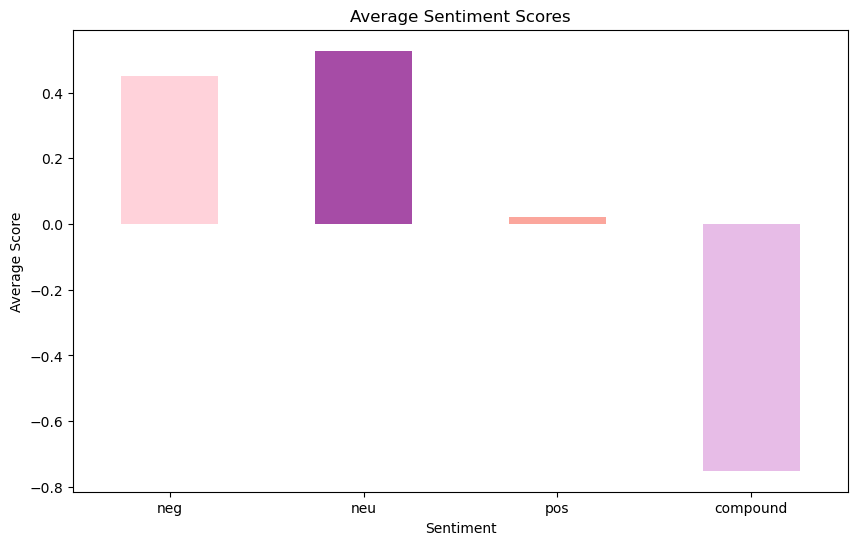

<bound method Series.mean of 0       -0.9509
1       -0.9509
2       -0.9509
3       -0.9509
4       -0.9509
          ...  
19403   -0.8271
19404    0.0000
19405   -0.9393
19406   -0.9217
19407   -0.7506
Name: compound, Length: 19408, dtype: float64>

<Figure size 640x480 with 0 Axes>

In [9]:
sentiment_df = pd.DataFrame(merged['sentiments'].tolist())

plt.figure(figsize=(10, 6))

sentiment_df.mean().plot(kind='bar', color=['pink', 'purple', 'salmon', 'plum'], alpha=0.7)
plt.title('Average Sentiment Scores')
plt.xlabel('Sentiment')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()
plt.savefig('output/sentiment_figure.png')

sentiment_df.compound.mean

(14360, 58)
(4955, 58)


/var/folders/sp/m42g974s16vdc06dp0p_mzmw0000gn/T/ipykernel_12391/621396426.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reeval_subset.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
/var/folders/sp/m42g974s16vdc06dp0p_mzmw0000gn/T/ipykernel_12391/621396426.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reeval_subset["sentiments"] = reeval_subset['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)


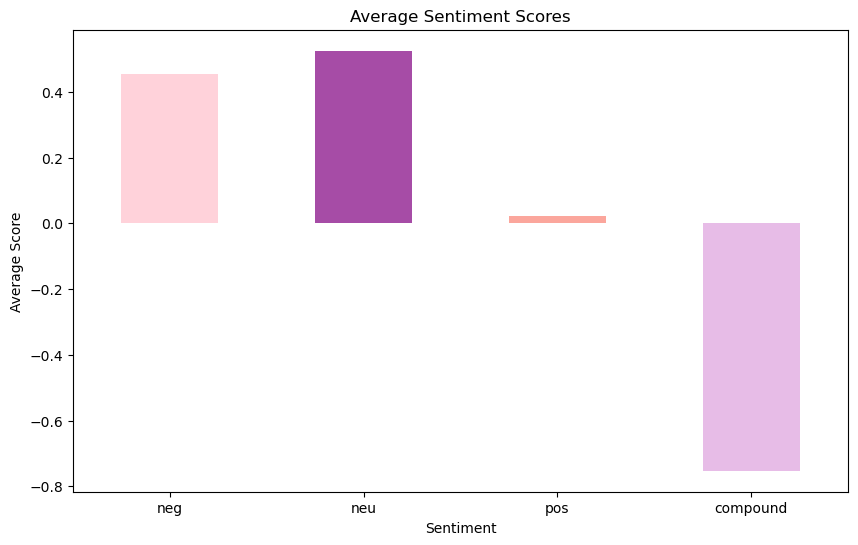

<bound method Series.mean of 0       -0.9509
1       -0.9509
2       -0.9509
3       -0.9509
4       -0.9509
          ...  
14355   -0.8271
14356    0.0000
14357   -0.9393
14358   -0.9217
14359   -0.7506
Name: compound, Length: 14360, dtype: float64>

<Figure size 640x480 with 0 Axes>

In [10]:
# ANNA: separating intake and re-eval 

# re-eval subset
reeval_subset = merged[merged['Type of Service'] == "Re-evaluation"]
print(reeval_subset.shape)

#intake subset
intake_subset = merged[merged['Type of Service'] == "Intake"]
print(intake_subset.shape)

merged.shape

merged['Type of Service'].unique()


sentiments = []
reeval_subset.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
sent_obj = SentimentIntensityAnalyzer()

reeval_subset["sentiments"] = reeval_subset['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)

reeval_subset["sentiments"]


reeval_df = pd.DataFrame(reeval_subset['sentiments'].tolist())

plt.figure(figsize=(10, 6))
reeval_df.mean().plot(kind='bar', color=['pink', 'purple', 'salmon', 'plum'], alpha=0.7)
plt.title('Average Sentiment Scores')
plt.xlabel('Sentiment')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()
plt.savefig('output/sentiment_reeval.png')

reeval_df.compound.mean

/var/folders/sp/m42g974s16vdc06dp0p_mzmw0000gn/T/ipykernel_12391/707929291.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intake_subset.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
/var/folders/sp/m42g974s16vdc06dp0p_mzmw0000gn/T/ipykernel_12391/707929291.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intake_subset["sentiments"] = intake_subset['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)


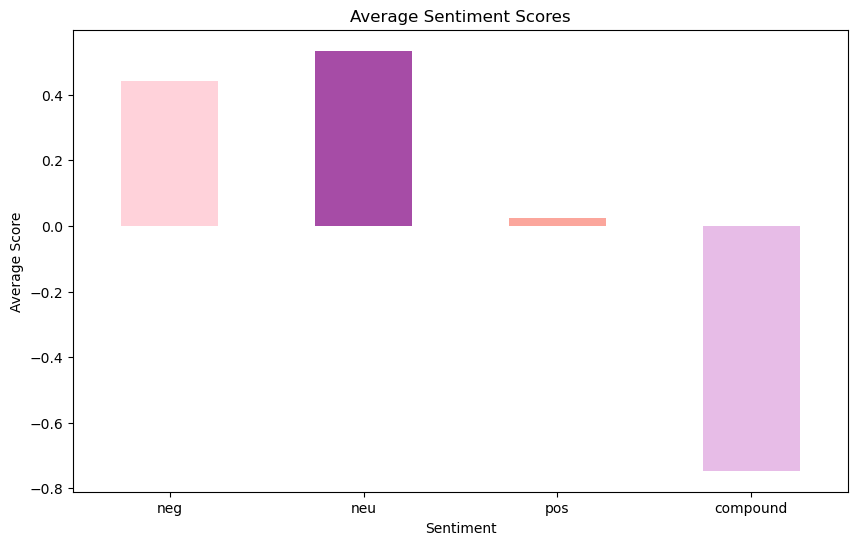

<bound method Series.mean of 0      -0.8271
1      -0.8271
2       0.3182
3      -0.7506
4      -0.7506
         ...  
4950    0.0000
4951   -0.9081
4952   -0.7506
4953   -0.8271
4954   -0.8271
Name: compound, Length: 4955, dtype: float64>

<Figure size 640x480 with 0 Axes>

In [11]:
sentiments = []
intake_subset.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
sent_obj = SentimentIntensityAnalyzer()

intake_subset["sentiments"] = intake_subset['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)

intake_subset["sentiments"]


intake_df = pd.DataFrame(intake_subset['sentiments'].tolist())

plt.figure(figsize=(10, 6))
intake_df.mean().plot(kind='bar', color=['pink', 'purple', 'salmon', 'plum'], alpha=0.7)
plt.title('Average Sentiment Scores')
plt.xlabel('Sentiment')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()
plt.savefig('output/sentiment_intake.png')
intake_df.compound.mean

In [12]:
# Grace  

grouped = merged.groupby('Type of Service')

# Calculate mean/median of normalized ABC scores for each type of score
mean_abc_scores = grouped[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()
median_abc_scores = grouped[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].median()

# Print mean and median ABC scores for intake VS reevaluation
print("Mean ABC Scores by Type of Service:")
print(mean_abc_scores)

print("Median ABC Scores by Type of Service:")
print(median_abc_scores)




Mean ABC Scores by Type of Service:
                           norm_leth_soc  norm_ir_agit  norm_stereo  \
Type of Service                                                       
Intake                         26.969068     48.840795    25.318666   
Re-evaluation                  20.082151     37.151033    18.492202   
Resource Center admission      19.847670     31.254480    12.454212   

                           norm_hyper  norm_speech  
Type of Service                                     
Intake                      46.043439    37.100480  
Re-evaluation               34.168355    29.463744  
Resource Center admission   25.452899    26.902174  
Median ABC Scores by Type of Service:
                           norm_leth_soc  norm_ir_agit  norm_stereo  \
Type of Service                                                       
Intake                         22.916667     48.888889    14.285714   
Re-evaluation                  14.583333     35.555556     9.523810   
Resource Center admis

In [6]:

# Grace's GENDER analysis 
gender_mapping = {
    'Female': 'Female',
    'Male': 'Male',
    'Other:': 'Other:',
    'Other: Born male, unsure of gender identity at this time': 'Other:',
    'Other: Born male/ he/ him, Currently identifies as female/ she/ her': 'Other:',
    'Other: Desires to transition from male to female': 'Other:',
    'Other: Identifies as female': 'Other:',
    'Other: Transgender female': 'Other:',
    'Other: biologically female. self describes as male': 'Other:',
    'Other: currently exploring male and female gender identities': 'Other:',
    'Other: non binary': 'Other:',
    'Other: not sure yet as to who Sam identifies with': 'Other:'
}


# Apply all of this gender mapping to the Gender column
merged['Gender'] = merged['Gender'].map(gender_mapping).fillna('Other:')



abc_by_gender = merged.groupby(['Type of Service', 'Gender'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()
print("Mean ABC Scores by Gender and Type of Service:")
abc_by_gender

KeyError: "Columns not found: 'norm_hyper', 'norm_speech', 'norm_leth_soc', 'norm_stereo', 'norm_ir_agit'"

In [8]:
# Grace

import pandas as pd

# Assuming abc_by_race_with_counts_sorted is your DataFrame

import pandas as pd

# Assuming abc_by_race_with_counts_sorted is your DataFrame

# Define a mapping dictionary for the new categories
race_mapping = {
    'White': 'White',
    'Black or African American': 'Black or African American',
    'Unknown, not collected': 'Unknown',
    'Other: Hispanic': 'Hispanic',
    'Asian': 'Asian',
    'Other': 'Other',
    'Black or African American, White': 'Multiracial',
    'Other: Latino': 'Hispanic',
    'American Indian or Alaska Native': 'American Indian or Alaska Native',
    'Other: hispanic': 'Hispanic',
    'Asian, White': 'Multiracial',
    'Other: Mexican': 'Hispanic',
    'Unknown, not collected, White': 'Unknown',
    'Native Hawaiian or Other Pacific Islander': 'Native Hawaiian or Other Pacific Islander',
    'Other: Biracial': 'Multiracial',
    'Other: Hispanic, White': 'Multiracial',
    'Other: Bi-racial': 'Multiracial',
    'Other: East Indian': 'Asian',
    'Asian, Black or African American': 'Multiracial',
    'Other: Indian': 'Asian',
    'Black or African American, Unknown, not collected': 'Multiracial',
    'Other: Middle Eastern': 'Other',
    'American Indian or Alaska Native, White': 'Multiracial',
    'Other: Guyanese': 'Unknown',
    'Other: Filipino': 'Unknown',
    'Other: Hispanic - Puerto Rican descent': 'Hispanic',
    'Other: Puerto Rican': 'Hispanic',
    'Other: Mixed race': 'Multiracial',
    'Other: Mixed Race': 'Multiracial',
    'Native Hawaiian or Other Pacific Islander, White': 'Multiracial',
    'Other: "Hispanic"': 'Hispanic',
    'Other: Latina': 'Hispanic',
    'Other: Latin  American': 'Hispanic',
    'Other: Jordanian': 'Unknown',
    'Other: Pakistan, Unknown, not collected': 'Unknown',
    'Other: Hispanic/Latino': 'Hispanic',
    'Black or African American, Other: Hispanic': 'Multiracial',
    'Black or African American, Other: Guyanese': 'Multiracial',
    'Other: Russian': 'Unknown',
    'Other: West Indian': 'Unknown',
    'Asian, Other: Indian': 'Multiracial',
    'Other: HISPANIC': 'Hispanic',
    'Other: Guyanses': 'Unknown',
    'Asian, Other: Pakistani': 'Asian',
    'American Indian or Alaska Native, Black or African American': 'Multiracial',
    'Other: Ethiopian': 'Unknown',
    'Other: Egyptian': 'Unknown',
    'Other: biracial': 'Multiracial',
    'Other: Colombian': 'Unknown',
    'Other: Did not want to Identity with Race or Ethnicity': 'Unknown',
    'Other: Dominican': 'Unknown',
    'Other: Chinese': 'Unknown',
    'Other: Eastern European': 'Unknown',
    'Other: Ecuador': 'Unknown',
    'Other: Ecuadorian': 'Unknown',
    'Other: Caucasian and African Amercian': 'Multiracial',
    'Other: Caucasian': 'White',
    'Other: Eurasian': 'Multiracial',
    'Other: Carribean Indian': 'Other',
    'Other: Filipino and Caucasian': 'Multiracial',
    'Other: Bosnian': 'Other',
    'Other: Black Hispanic': 'Multiracial',
    'Other: HIspanic': 'Hispanic',
    'Other: Hispanic ': 'Hispanic',
    'Other: Hispanic (Uruguayan/Dominican)': 'Hispanic',
    'Other: Hispanic - Puerto Rican': 'Hispanic',
    'Other: Hispanic, AA and white': 'Multiracial',
    'Other: Hispanic, Unknown, not collected': 'Hispanic',
    'Other: Bi-Racial': 'Multiracial',
    'Other: Hispanic/ Latina': 'Hispanic',
    'Other: Bengalii': 'Other',
    'Other: Hispanic: Puerto Rican': 'Hispanic',
    'Other: Hondurian': 'Hispanic',
    'Other: Bengali': 'Other',
    'Other: Indian of Guyanese decent': 'Multiracial',
    'Other: Indian which decent unknown': 'Asian',
    'Other: Iraq': 'Unknown',
    'Other: Iraqi': 'Unknown',
    'Other: Irish': 'Unknown',
    'Other: Israel': 'Unknown',
    'Other: Jamaican American': 'Black or African American',
    'Other: Jewish': 'Unknown',
    'Other: Bangladish': 'Unknown',
    'Other: Baltic ethnic group (Latvian)': 'Unknown',
    'Other: Arab': 'Other',
    'Other: Albian/European': 'Unknown',
    'Other: Latino ( Mexican & Puerto Rican )': 'Hispanic',
    'Other: Latino (Guatemalen & El Salvador)': 'Hispanic',
    'Other: Latino, White': 'Hispanic',
    'Other: MIXED RACE, White': 'Multiracial',
    'Other: MIddle Eastern- North African Descent, ': 'Other',
    'Other: Mauritius': 'Unknown',
    'Other: African-American/Vietnamese': 'Multiracial',
    'Other: Mexican/Puerto Rican': 'Unknown',
    'Other: Middle Eastern Decent': 'Other',
    'Other: South African': 'Unknown',
    'Other: South American': 'Unknown',
    'Other: Spanish': 'Unknown',
    'Other: Vietnamese': 'Unknown',
    'Other: Vietnamesse': 'Unknown',
    'Other: unknown': 'Unknown',
    'Other: White and Asian': 'Multiracial',
    'Other: White and Black or African America': 'Multiracial',
    'Other: puerto rican': 'Unknown',
    'Asian, Black or African American, White': 'Multiracial',
    'Asian, Native Hawaiian or Other Pacific Islander': 'Multiracial',
    'Asian, Other: Filipino': 'Multiracial',
    'Asian, Other: Hispanic': 'Multiracial',
    'Other: not checked off': 'Unknown',
    'Other: myanmar': 'Unknown',
    'Other: mother is white and father is 1/2 white': 'Multiracial',
    'Other: White, Hispanic': 'Multiracial',
    'Other: White/Indian': 'Multiracial',
    'Asian, Other: vietnamese': 'Multiracial',
    'Other: mixed race': 'Multiracial',
    'Other: hispanic, White': 'Multiracial',
    'Other: latino/white': 'Hispanic',
    'Other: mexican': 'Unknown',
    'American Indian or Alaska Native, Other: Native Hawaiian or Other Pacific Islander': 'Multiracial',
    'Other:': 'Other'  
}

# Group by "Type of Service" and "Race" and calculate mean ABC scores
merged['Race'] = merged['Race'].map(race_mapping).fillna('Other')

abc_by_race = merged.groupby(['Type of Service', 'Race'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()

race_counts = merged.groupby(['Type of Service', 'Race']).size().reset_index(name='Count')

abc_by_race_with_counts = pd.merge(abc_by_race, race_counts, on=['Type of Service', 'Race'])

intake_data = abc_by_race_with_counts[abc_by_race_with_counts['Type of Service'] == 'Intake']
reeval_data = abc_by_race_with_counts[abc_by_race_with_counts['Type of Service'] == 'Re-evaluation']
resource_center_data = abc_by_race_with_counts[abc_by_race_with_counts['Type of Service'] == 'Resource Center admission']

intake_data_sorted = intake_data.sort_values(by='Count', ascending=False)
reeval_data_sorted = reeval_data.sort_values(by='Count', ascending=False)
resource_center_data_sorted = resource_center_data.sort_values(by='Count', ascending=False)

abc_by_race_with_counts_sorted = pd.concat([intake_data_sorted, reeval_data_sorted, resource_center_data_sorted])

print("\nMean ABC Scores by Race and Type of Service with Counts (Sorted by Count within each Service Type):")
abc_by_race_with_counts_sorted



Mean ABC Scores by Race and Type of Service with Counts (Sorted by Count within each Service Type):


,Type of Service,Race,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech,Count
8,Intake,White,26.229146,48.870481,24.256792,45.191191,36.892909,3023
2,Intake,Black or African American,25.993432,47.498632,24.801391,46.741453,37.681159,1017
7,Intake,Unknown,29.088453,50.297552,26.734926,46.676587,37.542662,295
3,Intake,Hispanic,32.150901,49.987130,29.417172,47.691441,37.661499,261
1,Intake,Asian,30.709388,49.662447,31.042797,47.824367,37.341772,159
4,Intake,Multiracial,30.593093,51.211211,33.033033,52.834084,34.909910,111
6,Intake,Other,30.113636,50.764791,32.900433,47.808442,34.415584,78
0,Intake,American Indian or Alaska Native,30.709877,49.300412,21.693122,46.682099,36.728395,27
5,Intake,Native Hawaiian or Other Pacific Islander,18.958333,45.333333,21.428571,42.708333,50.833333,10
17,Re-evaluation,White,19.494502,37.008952,17.523055,33.424353,29.340278,8885


In [15]:

abc_by_disability = merged.groupby(['Type of Service', 'Level of Intellectual Disability'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()

# COUNT 
disability_counts = merged.groupby(['Type of Service', 'Level of Intellectual Disability']).size().reset_index(name='Count')

# Merge the mean scores WITHH the counts
abc_by_disability_with_counts = pd.merge(abc_by_disability, disability_counts, on=['Type of Service', 'Level of Intellectual Disability'])

intake_data_disability = abc_by_disability_with_counts[abc_by_disability_with_counts['Type of Service'] == 'Intake']
reeval_data_disability = abc_by_disability_with_counts[abc_by_disability_with_counts['Type of Service'] == 'Re-evaluation']
resource_center_data_disability = abc_by_disability_with_counts[abc_by_disability_with_counts['Type of Service'] == 'Resource Center admission']

intake_data_disability_sorted = intake_data_disability.sort_values(by='Count', ascending=False)
reeval_data_disability_sorted = reeval_data_disability.sort_values(by='Count', ascending=False)
resource_center_data_disability_sorted = resource_center_data_disability.sort_values(by='Count', ascending=False)

abc_by_disability_with_counts_sorted = pd.concat([intake_data_disability_sorted, reeval_data_disability_sorted, resource_center_data_disability_sorted])


print("\nMean ABC Scores by Level of Intellectual Disability and Type of Service with Counts (Sorted by Count within each Service Type):")
abc_by_disability_with_counts_sorted

# render this into somehting intuititve 
# heat map, x axis ordinal scale, 
# create pivot table where x axis is level of intellectual disability 

# use the text to predict on some y , could code intake and re-eval as dummies 


Mean ABC Scores by Level of Intellectual Disability and Type of Service with Counts (Sorted by Count within each Service Type):


,Type of Service,Level of Intellectual Disability,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech,Count
1,Intake,Mild,24.709842,46.687300,19.906577,43.161127,36.758097,2160
2,Intake,Moderate,27.511199,49.588307,28.607553,46.882897,39.436782,1455
6,Intake,Severe,32.398857,53.010847,38.221214,51.868953,30.857648,379
3,Intake,None noted,31.098024,52.286390,33.232016,51.665400,38.414634,329
4,Intake,Normal intelligence,29.422869,52.461593,24.427953,48.793150,36.688312,313
0,Intake,Borderline,26.116071,47.028219,20.937264,45.676257,38.293651,252
5,Intake,Profound,29.103535,51.986532,37.373737,49.021465,23.989899,66
8,Re-evaluation,Mild,18.614355,35.434081,14.943726,31.550794,28.690790,6490
9,Re-evaluation,Moderate,19.871210,37.409347,20.614236,34.792522,31.055759,4396
13,Re-evaluation,Severe,24.731250,42.424041,29.300000,41.512654,26.897359,1007


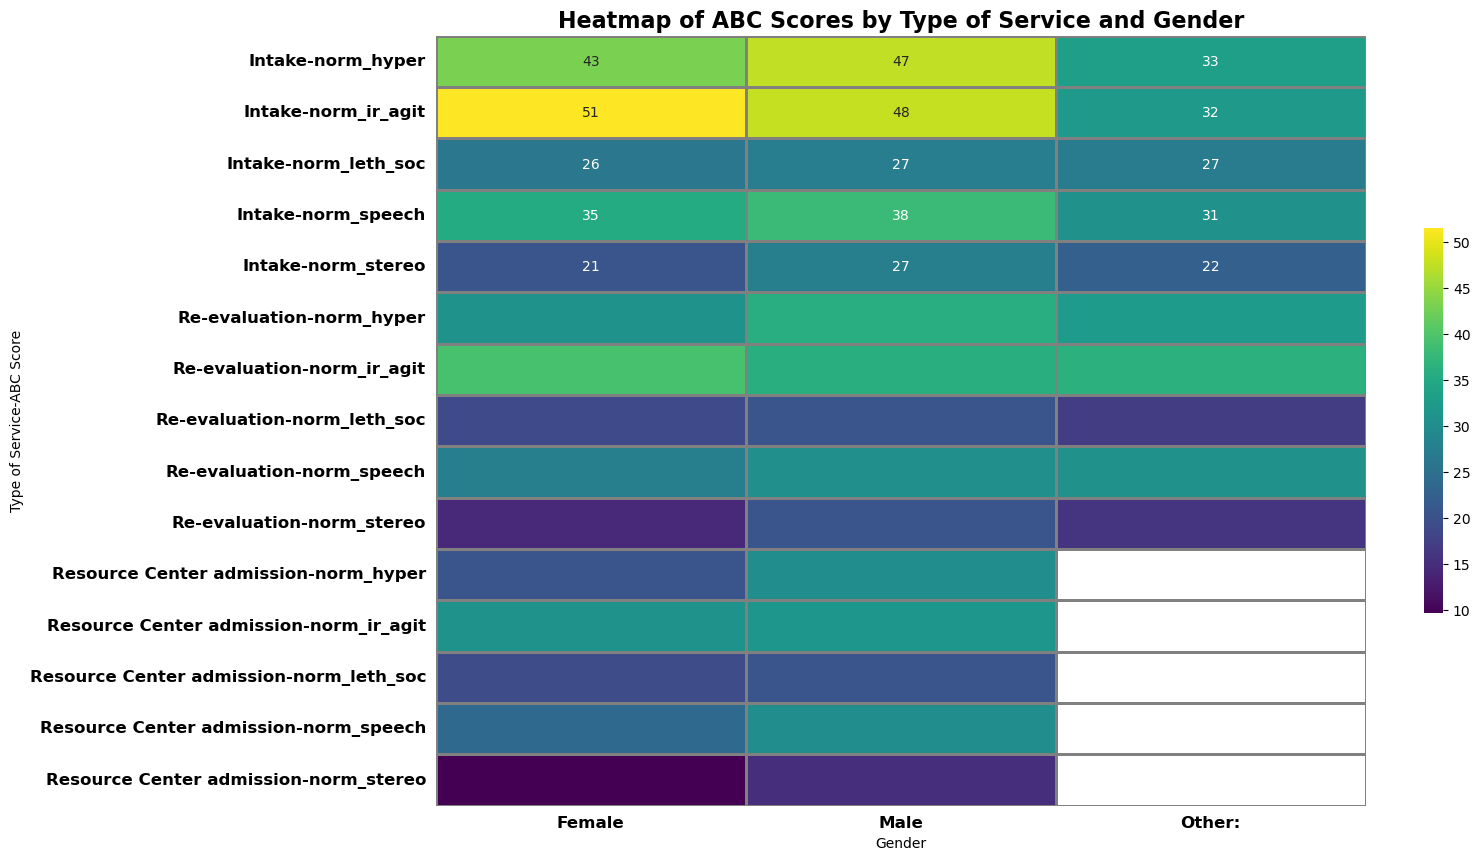

In [16]:
# making abc gender heat map 

abc_by_service_gender = merged.groupby(['Type of Service', 'Gender'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

#melt
abc_melted = abc_by_service_gender.melt(id_vars=['Type of Service', 'Gender'], 
                                        value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
                                        var_name='ABC Score', value_name='Mean Value')

# pivot 
abc_pivot = abc_melted.pivot_table(index=['Type of Service', 'ABC Score'], columns='Gender', values='Mean Value')

service_order = ['Intake', 'Re-evaluation', 'Resource Center admission']

abc_pivot = abc_pivot.reindex(service_order, level='Type of Service')

# heat
plt.figure(figsize=(15, 10))  # Adjusted dimensions
heatmap = sns.heatmap(
    abc_pivot,
    annot=True,  # Show numbers inside the map
    cmap='viridis',
    linewidths=1,  # Ensure lines between cells are visible
    linecolor='grey',  # Make the lines between cells grey
    cbar_kws={'shrink': 0.5}  # Adjust color bar size
)

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)
plt.title('Heatmap of ABC Scores by Type of Service and Gender', fontsize=16, fontweight='bold')
plt.show()


In [17]:
# making abc race heat map 

# making abc gender heat map 

abc_gender_pivot = df.pivot_table(index='Type of Service', columns='Gender', values=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'])

# Swap levels to get the desired hierarchical structure
abc_gender_pivot = abc_gender_pivot.swaplevel(axis=1).sort_index(axis=1)

# Plot the heat map with custom settings
plt.figure(figsize=(15, 4))  # Adjusted dimensions
heatmap = sns.heatmap(
    abc_gender_pivot,
    annot=False,  # Remove numbers inside the map
    cmap='viridis',
    linewidths=1,  # Ensure lines between cells are visible
    linecolor='grey',  # Make the lines between cells grey
    cbar_kws={'shrink': 0.5}  # Adjust color bar size
)

# Customizing the labels to be bold
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')

# Removing ticks
heatmap.tick_params(left=False, bottom=False)

# Adding a title
plt.title('Heatmap of Norms by Type of Service and Gender', fontsize=16, fontweight='bold')

# Show the heatmap
plt.show()

NameError: name 'df' is not defined

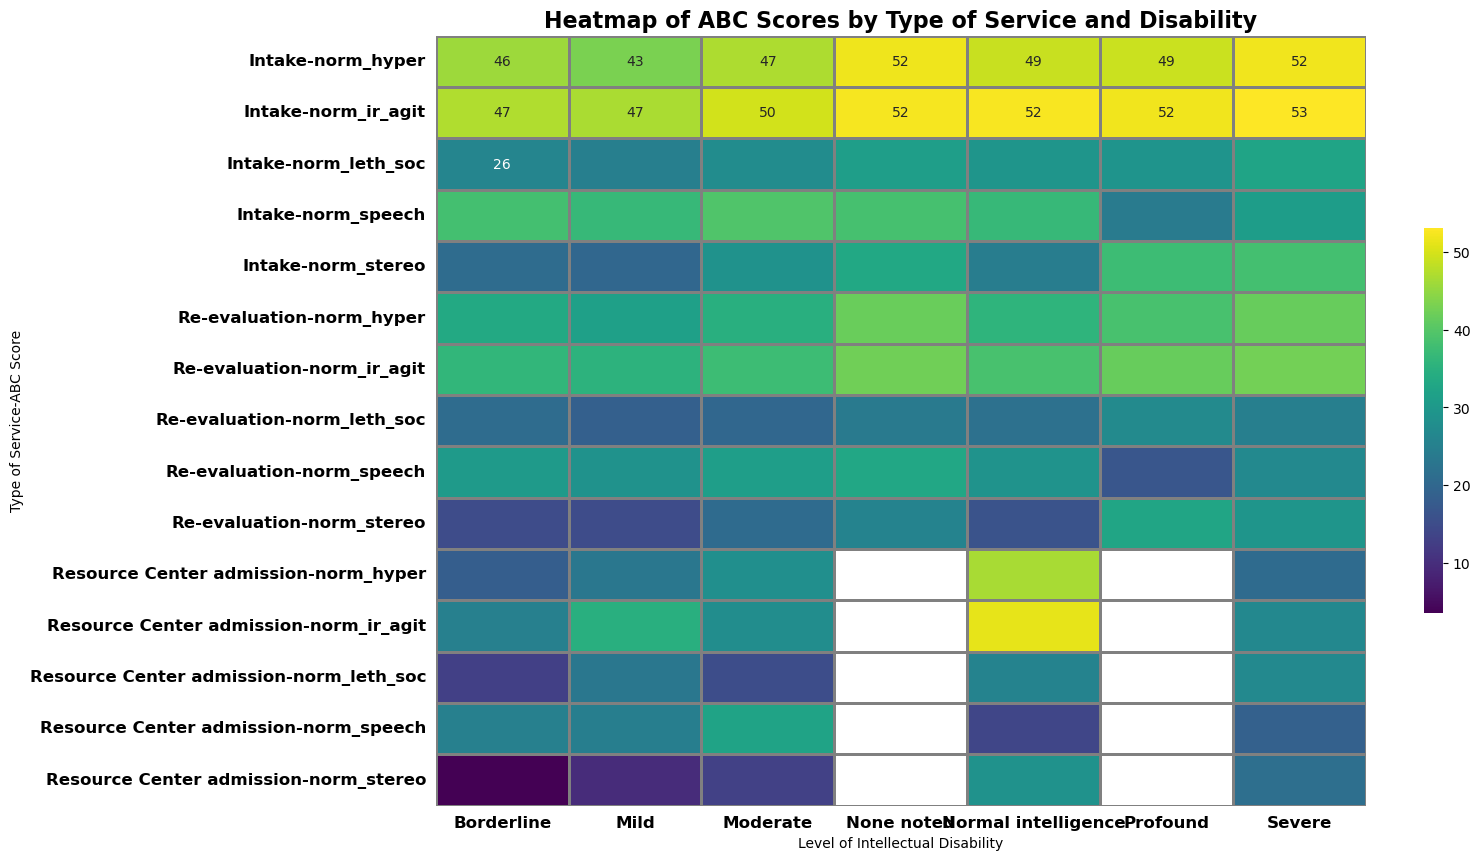

In [18]:
# making abc disability heat map 

abc_by_service_disability = merged.groupby(['Type of Service', 'Level of Intellectual Disability'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

#melt
abc_melted = abc_by_service_disability.melt(id_vars=['Type of Service', 'Level of Intellectual Disability'], 
                                        value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
                                        var_name='ABC Score', value_name='Mean Value')

# pivot 
abc_pivot = abc_melted.pivot_table(index=['Type of Service', 'ABC Score'], columns='Level of Intellectual Disability', values='Mean Value')

service_order = ['Intake', 'Re-evaluation', 'Resource Center admission']

abc_pivot = abc_pivot.reindex(service_order, level='Type of Service')

# heat
plt.figure(figsize=(15, 10))  # Adjusted dimensions
heatmap = sns.heatmap(
    abc_pivot,
    annot=True,  # Show numbers inside the map
    cmap='viridis',
    linewidths=1,  # Ensure lines between cells are visible
    linecolor='grey',  # Make the lines between cells grey
    cbar_kws={'shrink': 0.5}  # Adjust color bar size
)

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)
plt.title('Heatmap of ABC Scores by Type of Service and Disability', fontsize=16, fontweight='bold')
plt.show()


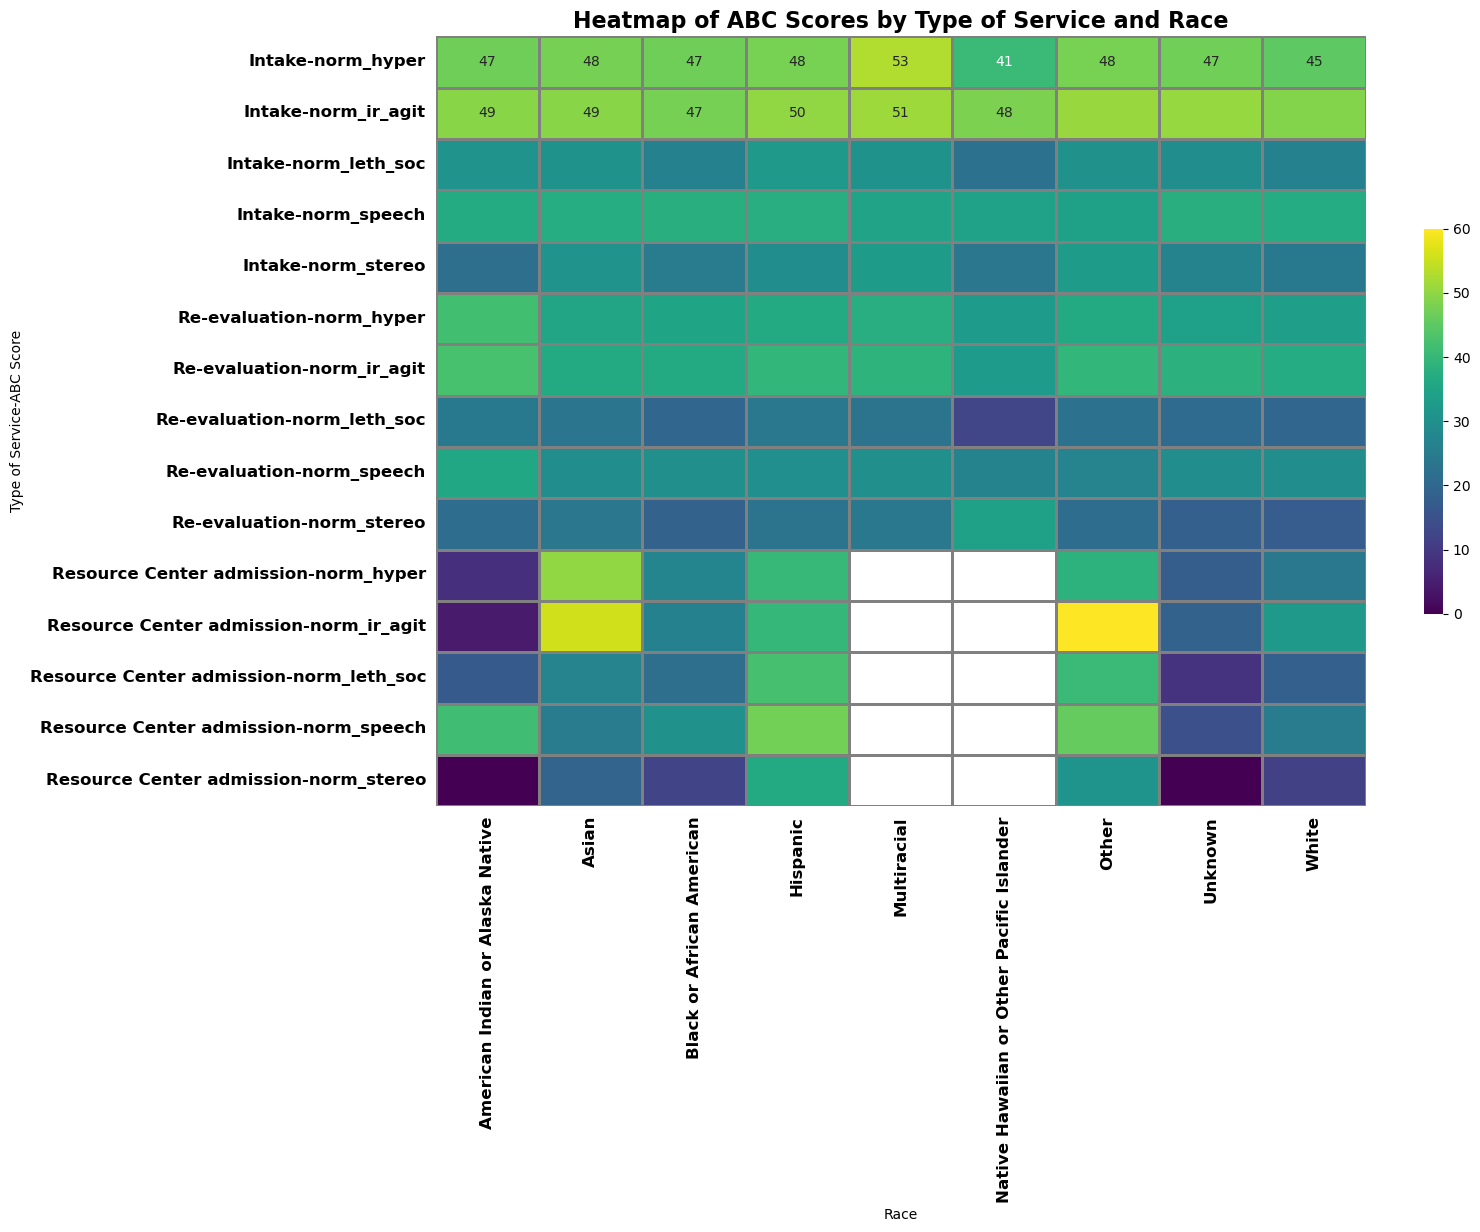

In [19]:
#race heat map 
abc_by_service_race = merged.groupby(['Type of Service', 'Race'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

#melt
abc_melted = abc_by_service_race.melt(id_vars=['Type of Service', 'Race'], 
                                        value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
                                        var_name='ABC Score', value_name='Mean Value')

# pivot 
abc_pivot = abc_melted.pivot_table(index=['Type of Service', 'ABC Score'], columns='Race', values='Mean Value')

service_order = ['Intake', 'Re-evaluation', 'Resource Center admission']

abc_pivot = abc_pivot.reindex(service_order, level='Type of Service')

# heat
plt.figure(figsize=(15, 10))  # Adjusted dimensions
heatmap = sns.heatmap(
    abc_pivot,
    annot=True,  # Show numbers inside the map
    cmap='viridis',
    linewidths=1,  # Ensure lines between cells are visible
    linecolor='grey',  # Make the lines between cells grey
    cbar_kws={'shrink': 0.5}  # Adjust color bar size
)

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)
plt.title('Heatmap of ABC Scores by Type of Service and Race', fontsize=16, fontweight='bold')
plt.show()

In [13]:
merged

,Local ID,Date Reviewed,Type of Service,Irritability/Agitation,Lethargy/Social Withdrawal,Stereotypic Behavior,Hyperactivity/Noncompliance,Inappropriate Speech,Date Enrolled in START,Status,...,Current IEP,Current 504 Plan,School Setting,Custody Status,Child Lives With,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech
0,11153125,10/26/2016,Re-evaluation,3.0,2.0,0.0,0.0,0.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,4.166667,6.666667,0.000000,0.000000,0.000000
1,11153125,4/11/2017,Re-evaluation,3.0,2.0,NaN,NaN,NaN,4/1/2013,Active,...,No,No,NaN,NaN,NaN,4.166667,6.666667,NaN,NaN,NaN
2,11153125,10/11/2017,Re-evaluation,2.0,1.0,0.0,0.0,NaN,4/1/2013,Active,...,No,No,NaN,NaN,NaN,2.083333,4.444444,0.000000,0.000000,NaN
3,11153125,6/21/2018,Re-evaluation,19.0,19.0,4.0,8.0,0.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,39.583333,42.222222,19.047619,16.666667,0.000000
4,11153125,9/24/2018,Re-evaluation,10.0,11.0,3.0,6.0,2.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,22.916667,22.222222,14.285714,12.500000,16.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19456,66474,11/29/2021,Re-evaluation,0.0,0.0,0.0,0.0,0.0,7/1/2020,Active,...,Yes: 2020-06-11,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
19457,445217,11/29/2021,Re-evaluation,8.0,6.0,5.0,11.0,1.0,4/1/2020,Active,...,Yes: 2019-03-21,No,Special school-in district,Parental custody,Parents,12.500000,17.777778,23.809524,22.916667,8.333333
19458,421066,12/3/2021,Re-evaluation,34.0,15.0,17.0,32.0,6.0,4/1/2020,Active,...,Yes: 2019-12-31,No,Separate classroom,Parental custody,Parents,31.250000,75.555556,80.952381,66.666667,50.000000
19459,312733,11/17/2021,Re-evaluation,5.0,1.0,0.0,5.0,1.0,5/1/2020,Active,...,No,No,Other: Not in school,Other: Adult who lives in supervised apartment...,Residential staff,2.083333,11.111111,0.000000,10.416667,8.333333


In [20]:
# Mary (Coefficient Plot)

# Columns of interest: Race, Gender, Level of Intellectual Disability, CPS History, Psychiatric, Moved in Past 5 Years

# Calculating Mean ABC Score Across All Columns 

cols_of_interest = merged[["Race", "Gender", "Level of Intellectual Disability", "More than one living situation over the last 5 years?",
                    "History of Child Protective Services involvement in past year (at enrollment to START)", 
                    "Psychiatric hospitalization in past year (at enrollment to START)"]]

mean_cols = merged[["norm_leth_soc", "norm_ir_agit", "norm_stereo", "norm_hyper", "norm_speech"]]

merged.dropna(subset=["norm_leth_soc", "norm_ir_agit", "norm_stereo", "norm_hyper", "norm_speech"], inplace = True)

merged["mean_abc"] = mean_cols.mean(axis = 1)


In [50]:
# Mapping Gender

mapping = {
    0: 'Male',
    1: 'Female'}

# Define the map_gender function
def map_gender(value):
    if value in mapping:
        return mapping[value]
    else:
        return 2

merged['Gender_mapped'] = merged['Gender'].apply(map_gender)

# Mapping Race

race_mapping = {
    'White': 'White',
    'Black or African American': 'Black or African American',
    'Unknown, not collected': 'Unknown',
    'Other: Hispanic': 'Hispanic',
    'Asian': 'Asian',
    'Other': 'Other',
    'Black or African American, White': 'Multiracial',
    'Other: Latino': 'Hispanic',
    'American Indian or Alaska Native': 'American Indian or Alaska Native',
    'Other: hispanic': 'Hispanic',
    'Asian, White': 'Multiracial',
    'Other: Mexican': 'Hispanic',
    'Unknown, not collected, White': 'Unknown',
    'Native Hawaiian or Other Pacific Islander': 'Native Hawaiian or Other Pacific Islander',
    'Other: Biracial': 'Multiracial',
    'Other: Hispanic, White': 'Multiracial',
    'Other: Bi-racial': 'Multiracial',
    'Other: East Indian': 'Asian',
    'Asian, Black or African American': 'Multiracial',
    'Other: Indian': 'Asian',
    'Black or African American, Unknown, not collected': 'Multiracial',
    'Other: Middle Eastern': 'Other',
    'American Indian or Alaska Native, White': 'Multiracial',
    'Other: Guyanese': 'Unknown',
    'Other: Filipino': 'Unknown',
    'Other: Hispanic - Puerto Rican descent': 'Hispanic',
    'Other: Puerto Rican': 'Hispanic',
    'Other: Mixed race': 'Multiracial',
    'Other: Mixed Race': 'Multiracial',
    'Native Hawaiian or Other Pacific Islander, White': 'Multiracial',
    'Other: "Hispanic"': 'Hispanic',
    'Other: Latina': 'Hispanic',
    'Other: Latin  American': 'Hispanic',
    'Other: Jordanian': 'Unknown',
    'Other: Pakistan, Unknown, not collected': 'Unknown',
    'Other: Hispanic/Latino': 'Hispanic',
    'Black or African American, Other: Hispanic': 'Multiracial',
    'Black or African American, Other: Guyanese': 'Multiracial',
    'Other: Russian': 'Unknown',
    'Other: West Indian': 'Unknown',
    'Asian, Other: Indian': 'Multiracial',
    'Other: HISPANIC': 'Hispanic',
    'Other: Guyanses': 'Unknown',
    'Asian, Other: Pakistani': 'Asian',
    'American Indian or Alaska Native, Black or African American': 'Multiracial',
    'Other: Ethiopian': 'Unknown',
    'Other: Egyptian': 'Unknown',
    'Other: biracial': 'Multiracial',
    'Other: Colombian': 'Unknown',
    'Other: Did not want to Identity with Race or Ethnicity': 'Unknown',
    'Other: Dominican': 'Unknown',
    'Other: Chinese': 'Unknown',
    'Other: Eastern European': 'Unknown',
    'Other: Ecuador': 'Unknown',
    'Other: Ecuadorian': 'Unknown',
    'Other: Caucasian and African Amercian': 'Multiracial',
    'Other: Caucasian': 'White',
    'Other: Eurasian': 'Multiracial',
    'Other: Carribean Indian': 'Other',
    'Other: Filipino and Caucasian': 'Multiracial',
    'Other: Bosnian': 'Other',
    'Other: Black Hispanic': 'Multiracial',
    'Other: HIspanic': 'Hispanic',
    'Other: Hispanic ': 'Hispanic',
    'Other: Hispanic (Uruguayan/Dominican)': 'Hispanic',
    'Other: Hispanic - Puerto Rican': 'Hispanic',
    'Other: Hispanic, AA and white': 'Multiracial',
    'Other: Hispanic, Unknown, not collected': 'Hispanic',
    'Other: Bi-Racial': 'Multiracial',
    'Other: Hispanic/ Latina': 'Hispanic',
    'Other: Bengalii': 'Other',
    'Other: Hispanic: Puerto Rican': 'Hispanic',
    'Other: Hondurian': 'Hispanic',
    'Other: Bengali': 'Other',
    'Other: Indian of Guyanese decent': 'Multiracial',
    'Other: Indian which decent unknown': 'Asian',
    'Other: Iraq': 'Unknown',
    'Other: Iraqi': 'Unknown',
    'Other: Irish': 'Unknown',
    'Other: Israel': 'Unknown',
    'Other: Jamaican American': 'Black or African American',
    'Other: Jewish': 'Unknown',
    'Other: Bangladish': 'Unknown',
    'Other: Baltic ethnic group (Latvian)': 'Unknown',
    'Other: Arab': 'Other',
    'Other: Albian/European': 'Unknown',
    'Other: Latino ( Mexican & Puerto Rican )': 'Hispanic',
    'Other: Latino (Guatemalen & El Salvador)': 'Hispanic',
    'Other: Latino, White': 'Hispanic',
    'Other: MIXED RACE, White': 'Multiracial',
    'Other: MIddle Eastern- North African Descent, ': 'Other',
    'Other: Mauritius': 'Unknown',
    'Other: African-American/Vietnamese': 'Multiracial',
    'Other: Mexican/Puerto Rican': 'Unknown',
    'Other: Middle Eastern Decent': 'Other',
    'Other: South African': 'Unknown',
    'Other: South American': 'Unknown',
    'Other: Spanish': 'Unknown',
    'Other: Vietnamese': 'Unknown',
    'Other: Vietnamesse': 'Unknown',
    'Other: unknown': 'Unknown',
    'Other: White and Asian': 'Multiracial',
    'Other: White and Black or African America': 'Multiracial',
        'Other: puerto rican': 'Unknown',
    'Asian, Black or African American, White': 'Multiracial',
    'Asian, Native Hawaiian or Other Pacific Islander': 'Multiracial',
    'Asian, Other: Filipino': 'Multiracial',
    'Asian, Other: Hispanic': 'Multiracial',
    'Other: not checked off': 'Unknown',
    'Other: myanmar': 'Unknown',
    'Other: mother is white and father is 1/2 white': 'Multiracial',
    'Other: White, Hispanic': 'Multiracial',
    'Other: White/Indian': 'Multiracial',
    'Asian, Other: vietnamese': 'Multiracial',
    'Other: mixed race': 'Multiracial',
    'Other: hispanic, White': 'Multiracial',
    'Other: latino/white': 'Hispanic',
    'Other: mexican': 'Unknown',
    'American Indian or Alaska Native, Other: Native Hawaiian or Other Pacific Islander': 'Multiracial',
    'Other:': 'Other'  
}

# Group by "Type of Service" and "Race" and calculate mean ABC scores
merged['Race_Fixed'] = merged['Race'].map(race_mapping).fillna('Other')

In [ ]:
# Creating Dummy Variables 

In [22]:
# Creating the Coefficient Plot 

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Fit linear regression model
model = sm.formula.ols(formula='mean_abc ~ C(race) + C(gender) + C(Level of Intellectual Disability) + C(More than one living situation over the last 5 years?) + C(History of Child Protective Services involvement in past year (at enrollment to START)) + C(Psychiatric hospitalization in past year (at enrollment to START))',
                       data = merged).fit()

# Get coefficients summary
coefs_sumz = model.params

coefs_std_err = model.bse

# Define outcome variable names
outcome_variables = ["Race", "Gender", "Level of Intellectual Disability",
                     "More than one living situation over the last 5 years?",
                     "History of Child Protective Services involvement in past year (at enrollment to START)",
                     "Psychiatric hospitalization in past year (at enrollment to START)"]

# Extract coefficients and standard errors
coefz_df = pd.DataFrame({
    'outcome': outcome_variables,
    
    'coefs': [coefs_sumz['Intercept'], coefs_sumz['race[T.1]'], coefs_sumz['gender'], coefs_sumz['C(Level of Intellectual Disability)[T.1]'], 
              coefs_sumz['C(More than one living situation over the last 5 years?)[T.1]'], coefs_sumz['C(History of Child Protective Services involvement in past year (at enrollment to START))[T.1]'], coefs_sumz['C(Psychiatric hospitalization in past year (at enrollment to START))[T.1]']],
    
    'ses': [coefs_std_err['Intercept'], coefs_std_err['race[T.1]'], coefs_std_err['gender'], coefs_std_err['C(Level of Intellectual Disability)[T.1]'], 
              coefs_std_err['C(More than one living situation over the last 5 years?)[T.1]'], coefs_std_err['C(History of Child Protective Services involvement in past year (at enrollment to START))[T.1]'], coefs_std_err['C(Psychiatric hospitalization in past year (at enrollment to START))[T.1]']]
})

# Plot coefficients
plt.figure(figsize = (10, 6))
sns.set_style("whitegrid")
sns.barplot(x = 'outcome', y = 'coefs', data = coefz_df, ci = None, color = 'skyblue')
plt.errorbar(x = coefz_df['outcome'], y = coefz_df['coefs'], yerr = 1.96*coefz_df['ses'], fmt = 'none', c = 'red', capsize = 5)
plt.axhline(y = 0, color = 'red', linestyle = '--', linewidth = 0.6)
plt.xlabel('Outcome')
plt.ylabel('Effect')
plt.title('Support of Nuclear Energy by Country')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()



PatsyError: error tokenizing input (maybe an unclosed string?)
    mean_abc ~ C(race) + C(gender) + C(Level of Intellectual Disability) + C(More than one living situation over the last 5 years?) + C(History of Child Protective Services involvement in past year (at enrollment to START)) + C(Psychiatric hospitalization in past year (at enrollment to START))
                                                                                                                                 ^

In [47]:
# Anna- trying out some ML stuff on data 

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score



demographics = ["Race", "Gender", "Level of Intellectual Disability", "More than one living situation over the last 5 years?", "History of Child Protective Services involvement in past year (at enrollment to START)", "Psychiatric hospitalization in past year (at enrollment to START)"]
abcs = ["norm_hyper", "norm_ir_agit", "norm_speech", "norm_stereo"]
X = merged[demographics]
y = merged["norm_hyper"]
y = y.astype(int)

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{report}')

# Preprocess new data similar to training data
new_data = pd.get_dummies(new_data, drop_first=True)

# Align the new_data columns with the training data columns
missing_cols = set(X.columns) - set(new_data.columns)
for col in missing_cols:
    new_data[col] = 0
new_data = new_data[X.columns]

# Standardize the new data
new_data_scaled = scaler.transform(new_data)

# Make predictions
new_predictions = model.predict(new_data_scaled)
print(new_predictions)

Mean Squared Error: 835.8170256942642
R^2 Score: -0.4743616055864599
Accuracy: 0.035297171035556706
Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.04      0.05        81
           2       0.04      0.05      0.05        82
           4       0.02      0.01      0.01       118
           6       0.01      0.01      0.01       110
           8       0.00      0.00      0.00       116
          10       0.04      0.06      0.05       104
          12       0.04      0.21      0.07       133
          14       0.03      0.04      0.04       131
          16       0.07      0.06      0.07       134
          18       0.05      0.04      0.04       119
          20       0.04      0.08      0.05       117
          22       0.03      0.05      0.03       122
          25       0.04      0.06      0.05       139
          27       0.03      0.11      0.05       112
          29       0.06      0.06      0.06       104
          31

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [25]:
improved_scores = merged.copy
merged['Date Reviewed'] = pd.to_datetime(merged['Date Reviewed'], errors='coerce', infer_datetime_format=True)


merged = merged.sort_values(by=['Local ID', 'Date Reviewed'])

# Get the intake (first entry) and last re-evaluation for each 'Local ID'
intake_df = merged.groupby('Local ID').first().reset_index()
last_reeval_df = merged.groupby('Local ID').last().reset_index()

# Merge the intake and last re-evaluation DataFrames
comparison_df = pd.merge(intake_df, last_reeval_df, on='Local ID', suffixes=('_intake', '_last_reeval'))

score_columns = ['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']
for score in score_columns:
    comparison_df[f'{score}_improved'] = (comparison_df[f'{score}_last_reeval'] > comparison_df[f'{score}_intake']).astype(int)

demographic_columns = ['Gender_intake', 'Race_intake', 'Level of Intellectual Disability_intake']

comparison_df = comparison_df[['Local ID'] + [f'{score}_improved' for score in score_columns] + demographic_columns]

# Display the results
comparison_df


/var/folders/sp/m42g974s16vdc06dp0p_mzmw0000gn/T/ipykernel_23903/2290141323.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged['Date Reviewed'] = pd.to_datetime(merged['Date Reviewed'], errors='coerce', infer_datetime_format=True)


,Local ID,norm_leth_soc_improved,norm_ir_agit_improved,norm_stereo_improved,norm_hyper_improved,norm_speech_improved,Gender_intake,Race_intake,Level of Intellectual Disability_intake
0,316234E,1,1,1,1,1,Male,White,Moderate
1,509088E,0,1,0,0,0,Female,White,None noted
2,000083W,0,1,1,0,0,Female,White,Mild
3,014816W,0,0,0,0,0,Male,White,Severe
4,021562E,0,0,0,1,0,Male,Black or African American,Mild
...,...,...,...,...,...,...,...,...,...
4817,Y384729,0,0,1,0,0,Male,White,Mild
4818,Y416645,0,0,0,0,0,Male,White,Mild
4819,Y524242,0,0,0,0,0,Female,White,Moderate
4820,Y895136,1,1,1,0,1,Female,White,Severe


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


df = pd.get_dummies(comparison_df, columns=demographic_columns, drop_first=True)

# Define features (X) and labels (y)
X = df.drop(columns=['Local ID', 'norm_leth_soc_improved', 'norm_ir_agit_improved', 'norm_stereo_improved', 'norm_hyper_improved', 'norm_speech_improved'])
y = df[['norm_leth_soc_improved', 'norm_ir_agit_improved', 'norm_stereo_improved', 'norm_hyper_improved', 'norm_speech_improved']]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a classifier for each ABC score improvement
classifiers = {}
for column in y.columns:
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train[column])
    classifiers[column] = clf

# Evaluate the model on the test set
for column, clf in classifiers.items():
    y_pred = clf.predict(X_test)
    print(f"Classification report for {column}:")
    print(classification_report(y_test[column], y_pred))

# Display the results
print(df.head())

Classification report for norm_leth_soc_improved:
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       689
           1       0.10      0.00      0.01       276

    accuracy                           0.71       965
   macro avg       0.41      0.50      0.42       965
weighted avg       0.54      0.71      0.59       965

Classification report for norm_ir_agit_improved:
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       746
           1       0.14      0.00      0.01       219

    accuracy                           0.77       965
   macro avg       0.46      0.50      0.44       965
weighted avg       0.63      0.77      0.67       965

Classification report for norm_stereo_improved:
              precision    recall  f1-score   support

           0       0.74      1.00      0.85       714
           1       0.25      0.00      0.01       251

    accuracy                       

In [29]:
# Extract unique races
races = comparison_df['Race_intake'].unique()

for race in races:
    print(f"Training and evaluating models for race: {race}")
    
    # Filter data for the specific race
    race_df = df[df[f'Race_intake_{race}'] == 1]
    
    # Define features (X) and labels (y) for this subgroup
    X_race = race_df.drop(columns=['Local ID', 'norm_leth_soc_improved', 'norm_ir_agit_improved', 'norm_stereo_improved', 'norm_hyper_improved', 'norm_speech_improved'])
    y_race = race_df[['norm_leth_soc_improved', 'norm_ir_agit_improved', 'norm_stereo_improved', 'norm_hyper_improved', 'norm_speech_improved']]
    
    # Split the data into training and testing sets
    X_train_race, X_test_race, y_train_race, y_test_race = train_test_split(X_race, y_race, test_size=0.2, random_state=42)
    
    # Initialize and train a classifier for each ABC score improvement
    classifiers_race = {}
    for column in y_race.columns:
        clf = RandomForestClassifier(random_state=42)
        clf.fit(X_train_race, y_train_race[column])
        classifiers_race[column] = clf
    
    # Evaluate the model on the test set
    for column, clf in classifiers_race.items():
        y_pred_race = clf.predict(X_test_race)
        print(f"Classification report for {column} (Race: {race}):")
        print(classification_report(y_test_race[column], y_pred_race))


Training and evaluating models for race: White
Classification report for norm_leth_soc_improved (Race: White):
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       416
           1       0.25      0.01      0.02       168

    accuracy                           0.71       584
   macro avg       0.48      0.50      0.42       584
weighted avg       0.58      0.71      0.60       584

Classification report for norm_ir_agit_improved (Race: White):
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       447
           1       0.00      0.00      0.00       137

    accuracy                           0.77       584
   macro avg       0.38      0.50      0.43       584
weighted avg       0.59      0.77      0.66       584

Classification report for norm_stereo_improved (Race: White):
              precision    recall  f1-score   support

           0       0.79      1.00      0.89       464
 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

Classification report for norm_leth_soc_improved (Race: Black or African American):
              precision    recall  f1-score   support

           0       0.74      0.99      0.85       145
           1       0.00      0.00      0.00        50

    accuracy                           0.74       195
   macro avg       0.37      0.50      0.42       195
weighted avg       0.55      0.74      0.63       195

Classification report for norm_ir_agit_improved (Race: Black or African American):
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       146
           1       1.00      0.02      0.04        49

    accuracy                           0.75       195
   macro avg       0.88      0.51      0.45       195
weighted avg       0.81      0.75      0.65       195

Classification report for norm_stereo_improved (Race: Black or African American):
              precision    recall  f1-score   support

           0       0.75      0.99      0.8

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

Classification report for norm_leth_soc_improved (Race: Other):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       0.00      0.00      0.00         2

    accuracy                           0.89        18
   macro avg       0.44      0.50      0.47        18
weighted avg       0.79      0.89      0.84        18

Classification report for norm_ir_agit_improved (Race: Other):
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        14
           1       0.00      0.00      0.00         4

    accuracy                           0.78        18
   macro avg       0.39      0.50      0.44        18
weighted avg       0.60      0.78      0.68        18

Classification report for norm_stereo_improved (Race: Other):
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        14
           1       0.00      0.00      0.00     

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

Classification report for norm_leth_soc_improved (Race: Asian):
              precision    recall  f1-score   support

           0       0.76      0.86      0.81        22
           1       0.40      0.25      0.31         8

    accuracy                           0.70        30
   macro avg       0.58      0.56      0.56        30
weighted avg       0.66      0.70      0.67        30

Classification report for norm_ir_agit_improved (Race: Asian):
              precision    recall  f1-score   support

           0       0.86      0.92      0.89        26
           1       0.00      0.00      0.00         4

    accuracy                           0.80        30
   macro avg       0.43      0.46      0.44        30
weighted avg       0.74      0.80      0.77        30

Classification report for norm_stereo_improved (Race: Asian):
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        23
           1       0.00      0.00      0.00     

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

KeyError: 'Race_intake_American Indian or Alaska Native'

In [30]:
# Extract unique genders
genders = comparison_df['Gender_intake'].unique()

for gender in genders:
    print(f"Training and evaluating models for gender: {gender}")
    
    # Filter data for the specific gender
    gender_df = df[df[f'Gender_intake_{gender}'] == 1]
    
    # Define features (X) and labels (y) for this subgroup
    X_gender = gender_df.drop(columns=['Local ID', 'norm_leth_soc_improved', 'norm_ir_agit_improved', 'norm_stereo_improved', 'norm_hyper_improved', 'norm_speech_improved'])
    y_gender = gender_df[['norm_leth_soc_improved', 'norm_ir_agit_improved', 'norm_stereo_improved', 'norm_hyper_improved', 'norm_speech_improved']]
    
    # Split the data into training and testing sets
    X_train_gender, X_test_gender, y_train_gender, y_test_gender = train_test_split(X_gender, y_gender, test_size=0.2, random_state=42)
    
    # Initialize and train a classifier for each ABC score improvement
    classifiers_gender = {}
    for column in y_gender.columns:
        clf = RandomForestClassifier(random_state=42)
        clf.fit(X_train_gender, y_train_gender[column])
        classifiers_gender[column] = clf
    
    # Evaluate the model on the test set
    for column, clf in classifiers_gender.items():
        y_pred_gender = clf.predict(X_test_gender)
        print(f"Classification report for {column} (Gender: {gender}):")
        print(classification_report(y_test_gender[column], y_pred_gender))



Training and evaluating models for gender: Male
Classification report for norm_leth_soc_improved (Gender: Male):
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       502
           1       0.33      0.01      0.01       162

    accuracy                           0.75       664
   macro avg       0.54      0.50      0.44       664
weighted avg       0.65      0.75      0.65       664

Classification report for norm_ir_agit_improved (Gender: Male):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       531
           1       0.00      0.00      0.00       133

    accuracy                           0.80       664
   macro avg       0.40      0.50      0.44       664
weighted avg       0.64      0.80      0.71       664

Classification report for norm_stereo_improved (Gender: Male):
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       5

KeyError: 'Gender_intake_Female'

In [79]:
unique_df = merged.drop_duplicates(subset='Local ID')
race_counts = pd.DataFrame(unique_df.Race_Fixed.value_counts())

gender_counts = pd.DataFrame(unique_df.Gender.value_counts())

race_counts

,count
Race_Fixed,
White,2917
Black or African American,974
Unknown,286
Hispanic,266
Asian,147
Multiracial,109
Other,89
American Indian or Alaska Native,27
Native Hawaiian or Other Pacific Islander,7
